# 📣 AI Marketing Campaign Generator
## Hierarchical Agent Architecture using LangGraph + Groq

---

### 🏗️ Architecture: Hierarchical Agents (3-Tier Company Structure)

```
                        CEO AGENT
                    (Campaign Strategist)
                 /           |           \
          SEO Manager   Social Manager   Email Manager
           /     \         /     \          /     \
       Keyword   Blog   Caption  Hashtag  Subject  Body
       Worker   Worker   Worker   Worker   Worker  Worker
```

### 🗂️ 3-Tier Breakdown
| Tier | Role | Agents | Reads From | Writes To |
|------|------|--------|------------|-----------|
| Tier 1 (CEO) | Strategy | CEO Agent | User brief | Campaign strategy |
| Tier 2 (Managers) | Planning | SEO, Social, Email Managers | CEO strategy | Channel briefs |
| Tier 3 (Workers) | Execution | 6 Worker Agents | Manager briefs | Final content |

---

### 🔄 How Hierarchical Differs from All Previous Architectures

```
Sequential (P5):     A -> B -> C -> END         (linear, 1 agent at a time)
Router (P3,P4):      Router -> ONE agent -> END  (fan-out, select 1)
Supervisor (P1,P2):  Supervisor <-> Agents       (loop, dynamic order)
Collaborative (P6):  Agent A <-> Agent B -> Judge (debate loop)
Hierarchical (THIS): CEO -> Managers -> Workers  (parallel tiers, delegation)

KEY DIFFERENCE:
  Multiple agents run in PARALLEL per tier
  Each tier DELEGATES to the tier below
  Workers are fully SPECIALIZED (do 1 thing only)
  LangGraph parallelism: multiple edges from same source = parallel runs
```

### Temperature Ladder Across the Hierarchy
```
CEO (0.6)           -> Strategically distinctive, structured
Managers (0.3-0.5)  -> Precisely planned, tactical
Workers (0.7-0.9)   -> Maximum creative output <- highest here
```

---

### Step 0: Loading Environment & Liabraries

In [33]:
from dotenv import load_dotenv
load_dotenv()
import os

In [34]:
# pydantic: For structured data validation
from pydantic import BaseModel, Field

# LangChain components for prompts and parsing
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.output_parsers import PydanticOutputParser

# LangChain message types
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# LangChain runnable
from langchain_core.runnables import RunnablePassthrough

# LangGraph
from langgraph.graph import StateGraph, END

### Step 1: Loading/Initializing LLM

In [35]:
from langchain_groq import ChatGroq

# Groq automatically reads GROQ_API_KEY from environment variables

model = ChatGroq(
    model="llama-3.3-70b-versatile",   # or llama-3.3-70b-versatile
    temperature=0.7
)

llm = model

In [36]:
# ---- TEST ----
try:
    response = llm.invoke("Say hello in one sentence.")
    print("✅ Groq LLM initialized successfully")
    print("Response:", response.content)

except Exception as e:
    print("❌ Groq LLM initialization failed")
    print(e)

✅ Groq LLM initialized successfully
Response: Hello, it's nice to meet you and I'm here to help with any questions or topics you'd like to discuss.


## Step 2 — Shared State Definition

### State Design: The Company's Shared Drive

In Hierarchical Architecture the state acts like a company memo board.
Each tier writes deliverables that the tier below reads before executing.

```
State fill order (reflects the 3-tier hierarchy):

Tier 0 (Input):     product_brief       <- user provides

Tier 1 (CEO):       campaign_strategy   <- CEO writes; ALL managers read

Tier 2 (Managers,   seo_brief           <- SEO Manager writes
 run in parallel):  social_brief        <- Social Manager writes
                    email_brief         <- Email Manager writes

Tier 3 (Workers,    seo_keywords        <- Keyword Worker writes
 run in parallel):  blog_post           <- Blog Worker writes
                    social_captions     <- Caption Worker writes
                    hashtag_sets        <- Hashtag Worker writes
                    email_subjects      <- Subject Worker writes
                    email_body          <- Body Worker writes
```

Each field is OWNED by exactly one agent — no field is written twice.

In [37]:
from typing import TypedDict, Optional
from typing import TypedDict, Optional, Annotated
import operator



class CampaignState(TypedDict):
    """
    Shared state for the Marketing Campaign Generator.

    Think of this as the company's shared Google Drive:
    - CEO writes the strategy doc  -> everyone can read it
    - Each Manager writes a brief  -> their workers read it
    - Each Worker writes content   -> it goes into the final campaign

    Key insight: unlike Supervisor/Router states which need
    routing fields (next_agent, route), Hierarchical state
    is PURE DATA — the graph structure handles the order.
    """

    # Tier 0: User Input
    # Plain-English product/campaign brief from the user
    product_brief: str

    # Tier 1: CEO Output
    # Master strategy — ALL managers and workers eventually read this
    # This is the North Star that keeps all 8 downstream agents aligned
    campaign_strategy: Optional[str]

    # Tier 2: Manager Outputs (channel-specific execution plans)
    # Each manager translates CEO strategy into worker-ready instructions
    seo_brief:    Optional[str]   # -> read by Keyword Worker + Blog Worker
    social_brief: Optional[str]   # -> read by Caption Worker + Hashtag Worker
    email_brief:  Optional[str]   # -> read by Subject Worker + Body Worker

    # Tier 3: Worker Outputs (actual publishable content)
    # SEO deliverables
    seo_keywords: Optional[str]      # keyword research report
    blog_post:    Optional[str]      # full SEO-optimized blog article

    # Social media deliverables
    social_captions: Optional[str]   # platform-specific captions
    hashtag_sets:    Optional[str]   # curated hashtag sets per platform

    # Email deliverables
    email_subjects: Optional[str]    # A/B test subject line variants
    email_body:     Optional[str]    # full email copy

    # # Event log
    # messages: list

   
    # AFTER (parallel-safe):
    messages: Annotated[list, operator.add]


print("CampaignState defined!")
print(f"   Total fields: {len(CampaignState.__annotations__)}")
print("   Tier 1 -> 1 output | Tier 2 -> 3 outputs | Tier 3 -> 6 outputs")
print("   Each field owned by exactly ONE agent")

CampaignState defined!
   Total fields: 12
   Tier 1 -> 1 output | Tier 2 -> 3 outputs | Tier 3 -> 6 outputs
   Each field owned by exactly ONE agent


## Step 3 — Tier 1: CEO Agent (Campaign Strategist)

The CEO runs FIRST and ALONE. Every single agent below reads this output.
Bad CEO strategy = all 8 downstream agents produce misaligned content.
Good CEO strategy = all 8 agents naturally reinforce each other.

This is the most important agent in the hierarchy.

In [38]:
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage


def ceo_agent(state: dict) -> dict:
    """
    Tier 1 — CEO Agent: Sets the master campaign strategy.

    Runs FIRST, alone. All managers and workers read this output.
    The strategy it writes is the 'North Star' for the entire campaign.

    Reads:  state['product_brief']     (user input)
    Writes: state['campaign_strategy'] (read by ALL Tier 2 managers)

    Temperature 0.6: strategic + distinctive, not generic
    """
    print("\n" + "="*60)
    print("CEO AGENT [Tier 1] — Setting master campaign strategy...")
    print("="*60)
    print(f"   Brief : {state['product_brief'][:80]}...")
    print("   Output: campaign_strategy -> read by ALL 3 managers")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.6,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a world-class Chief Marketing Officer (CMO)
with experience launching campaigns for Fortune 500 brands.

Your job: Read the product brief and write a MASTER CAMPAIGN STRATEGY
that three channel managers (SEO, Social Media, Email) will independently
use to create channel-specific content.

The strategy must be clear enough that managers can execute
WITHOUT asking follow-up questions.

Structure your output EXACTLY as:

MASTER CAMPAIGN STRATEGY
========================

## Campaign Name
[A memorable, punchy campaign name]

## Brand Voice and Tone
[3-5 adjectives + 1 sentence. What we sound like vs what we DON'T.]

## Target Audience
- Primary  : [specific persona — age, job, pain points]
- Secondary: [secondary persona]
- Values   : [psychographic — values, aspirations, lifestyle]

## Core Campaign Message
[Single central idea ALL content must reinforce — one sentence]

## Key Selling Points
[Top 4 product benefits, ranked by audience resonance]

## Channel Strategy
- SEO Priority   : [what organic search should achieve]
- Social Priority: [what social should achieve]
- Email Priority : [what email should achieve]

## What to AVOID
[3-4 off-brand or counterproductive directions]

## Manager Instructions
- To SEO Manager   : [specific angle for SEO content]
- To Social Manager: [specific style for social content]
- To Email Manager : [specific funnel stage for email]"""),

        HumanMessage(content=f"Product Brief:\n\n{state['product_brief']}")
    ]

    response = llm.invoke(messages)
    strategy = response.content

    print(f"   Strategy written: {len(strategy)} chars")
    print("   -> Delegating to SEO Manager, Social Manager, Email Manager")

    return {
        "campaign_strategy": strategy,
        "messages": state["messages"] + [
            {"role": "ceo",
             "content": "[Tier 1] Master strategy set. Delegating to 3 channel managers."}
        ]
    }


print("CEO Agent (Tier 1) defined!")
print("   Reads: product_brief | Writes: campaign_strategy")
print("   Runs: First, alone | Temp: 0.6")

CEO Agent (Tier 1) defined!
   Reads: product_brief | Writes: campaign_strategy
   Runs: First, alone | Temp: 0.6


## Step 4 — Tier 2: The Three Channel Managers

All 3 Managers run IN PARALLEL after the CEO finishes.
They all read the SAME CEO strategy but translate it into DIFFERENT channel briefs.

Manager's job = TRANSLATION, not creation:
  CEO says: 'Focus on organic discovery for fitness professionals'
  SEO Manager says: 'Target long-tail keywords in running shoe comfort cluster,
                     write 1500-word pillar blog targeting best cushioned shoes 2024'

The Manager makes CEO strategy EXECUTABLE for workers.

In [39]:
def seo_manager(state: dict) -> dict:
    """
    Tier 2 — SEO Manager: Translates CEO strategy into SEO execution plan.

    Runs IN PARALLEL with Social Manager + Email Manager.
    All 3 read the same CEO output but produce DIFFERENT channel briefs.

    Reads:  state['campaign_strategy'] (CEO)
            state['product_brief']     (for product context)
    Writes: state['seo_brief']         (read by Keyword Worker + Blog Worker)
    Temperature 0.3: tactical planning needs precision, not creativity
    """
    print("\n" + "-"*60)
    print("SEO MANAGER [Tier 2] — Creating SEO execution plan...")
    print("-"*60)
    print("   Runs IN PARALLEL with Social Manager + Email Manager")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.3,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are an expert SEO Manager.
You've received the master campaign strategy from the CMO.
Translate it into a precise SEO execution brief for two workers:
a Keyword Researcher and a Blog Writer.

SEO CHANNEL BRIEF
=================

## SEO Objective
[What organic search should achieve for this campaign]

## To: Keyword Research Worker
- Focus clusters   : [3-4 topic clusters]
- Search intent    : [informational / commercial / transactional]
- Difficulty range : [low / medium / high competition]
- Volume target    : [broad high-volume OR specific intent]

## To: Blog Writing Worker
- Target topic  : [specific blog title]
- Primary keyword: [exact match keyword to rank for]
- Word count    : [target word count]
- Format        : [how-to / listicle / comparison / pillar / story]
- Key sections  : [H2 subheadings to cover]
- CTA at end    : [what readers should do after reading]

## SEO Success Metrics
[2-3 KPIs for SEO performance]"""),

        HumanMessage(content=f"""
Product: {state['product_brief']}

CEO Strategy:
{state.get('campaign_strategy', '')}
""")
    ]

    response = llm.invoke(messages)
    brief    = response.content
    print(f"   SEO brief written: {len(brief)} chars -> Keyword + Blog Workers")

    return {
        "seo_brief": brief,
        "messages": state["messages"] + [
            {"role": "seo_manager",
             "content": "[Tier 2] SEO brief created. -> Keyword Worker + Blog Worker"}
        ]
    }


def social_manager(state: dict) -> dict:
    """
    Tier 2 — Social Media Manager: Translates CEO strategy into social plan.

    Runs IN PARALLEL with SEO Manager + Email Manager.

    Reads:  state['campaign_strategy'] (CEO)
    Writes: state['social_brief']      (read by Caption Worker + Hashtag Worker)
    Temperature 0.5: social planning needs some creative flair
    """
    print("\n" + "-"*60)
    print("SOCIAL MANAGER [Tier 2] — Creating social execution plan...")
    print("-"*60)
    print("   Runs IN PARALLEL with SEO Manager + Email Manager")

    llm = ChatGroq(
        model="llama-3.3-70b-versatile",
        temperature=0.5,
        api_key=os.getenv("GROQ_API_KEY")
    )

    messages = [
        SystemMessage(content="""You are an expert Social Media Manager.
Translate the master campaign strategy into a social media execution brief
for two workers: a Caption Writer and a Hashtag Researcher.

SOCIAL MEDIA CHANNEL BRIEF
==========================

## Social Objective
[Awareness / Engagement / Conversion / Community — primary goal]

## To: Caption Writing Worker
- Platforms  : [Instagram / TikTok / LinkedIn / Twitter/X]
- Content pillars (types of posts to create):
  1. [Product showcase]
  2. [User testimonial/social proof]
  3. [Educational value]
- Caption tone per platform:
  - Instagram: [tone]
  - TikTok   : [tone]
  - LinkedIn : [tone]
- Hook style: [question / bold statement / statistic / story]
- CTA style : [follow / shop / swipe / comment / share]

## To: Hashtag Research Worker
- Niche hashtags   : [core topic hashtags]
- Community hashtags: [audience community hashtags]
- Campaign hashtag : [unique branded hashtag to create]
- Platform notes   : [hashtag count targets per platform]

## Social Success Metrics
[Engagement rate, reach, virality targets]"""),

        HumanMessage(content=f"""
Product: {state['product_brief']}

CEO Strategy:
{state.get('campaign_strategy', '')}
""")
    ]

    response = llm.invoke(messages)
    brief    = response.content
    print(f"   Social brief written: {len(brief)} chars -> Caption + Hashtag Workers")

    return {
        "social_brief": brief,
        "messages": state["messages"] + [
            {"role": "social_manager",
             "content": "[Tier 2] Social brief created. -> Caption Worker + Hashtag Worker"}
        ]
    }


def email_manager(state: dict) -> dict:
    """
    Tier 2 — Email Manager: Translates CEO strategy into email execution plan.

    Runs IN PARALLEL with SEO Manager + Social Manager.
    Email is highest-conversion channel — most specific about funnel stage.

    Reads:  state['campaign_strategy'] (CEO)
    Writes: state['email_brief']       (read by Subject Worker + Body Worker)
    Temperature 0.3: email planning is precise, conversion-focused
    """
    print("\n" + "-"*60)
    print("EMAIL MANAGER [Tier 2] — Creating email execution plan...")
    print("-"*60)
    print("   Runs IN PARALLEL with SEO Manager + Social Manager")

    llm = ChatGroq(
        model="llama-3.3-70b-versatile",
        temperature=0.3,
        api_key=os.getenv("GROQ_API_KEY")
    )

    messages = [
        SystemMessage(content="""You are an expert Email Marketing Manager.
Translate the master campaign strategy into a precise email brief
for two workers: a Subject Line Writer and an Email Body Copywriter.

EMAIL MARKETING CHANNEL BRIEF
=============================

## Email Objective
[Awareness / Nurture / Conversion / Retention + funnel stage TOFU/MOFU/BOFU]

## Recipient Persona
[Who is this email for? What is their biggest objection to buying?]

## To: Subject Line Writing Worker
- Urgency level  : [high / medium / low]
- Curiosity level: [high / medium / low]
- Emoji usage    : [yes / no]
- Length target  : [short <40 chars / medium 40-60 / long 60+]
- A/B test angle : [what variable to test — curiosity vs urgency?]
- Avoid          : [spam triggers or off-brand phrases]

## To: Email Body Writing Worker
- Email type  : [promotional / story / educational / product launch]
- Opening hook: [pain point / story / stat / bold claim]
- Core message: [ONE thing the email must convey]
- Proof needed: [testimonials, data, social proof to include]
- Primary CTA : [button text + destination]
- Tone        : [formal / conversational / urgent / friendly]
- Length      : [short ~150 / medium ~300 / long ~500+ words]

## Email Success Metrics
[Open rate, CTR, conversion targets]"""),

        HumanMessage(content=f"""
Product: {state['product_brief']}

CEO Strategy:
{state.get('campaign_strategy', '')}
""")
    ]

    response = llm.invoke(messages)
    brief    = response.content
    print(f"   Email brief written: {len(brief)} chars -> Subject + Body Workers")

    return {
        "email_brief": brief,
        "messages": state["messages"] + [
            {"role": "email_manager",
             "content": "[Tier 2] Email brief created. -> Subject Worker + Body Worker"}
        ]
    }


print("All 3 Tier-2 Managers defined!")
print("   seo_manager    -> seo_brief")
print("   social_manager -> social_brief")
print("   email_manager  -> email_brief")
print("   All 3 run IN PARALLEL after CEO finishes")

All 3 Tier-2 Managers defined!
   seo_manager    -> seo_brief
   social_manager -> social_brief
   email_manager  -> email_brief
   All 3 run IN PARALLEL after CEO finishes


## Step 5 — Tier 3: SEO Worker Agents

Workers are the most specialized agents. They do ONE thing only.
Workers READ BOTH the CEO strategy (for brand voice) AND
their Manager's brief (for specific task instructions).

This dual-read is key to Hierarchical architecture:
workers never lose sight of top-level strategy even when
executing very specific tasks.

In [40]:
def keyword_worker(state: dict) -> dict:
    """
    Tier 3 — Keyword Research Worker (reports to SEO Manager).

    ONLY researches and organizes keywords. Nothing else.
    This extreme specialization = expert-quality output.

    Reads:  state['campaign_strategy'] (CEO — brand context)
            state['seo_brief']         (SEO Manager — specific targeting)
    Writes: state['seo_keywords']      (deliverable)
    Runs IN PARALLEL with blog_worker.
    """
    print("\n  KEYWORD WORKER [Tier 3/SEO] — Researching keywords...")
    print("   Runs IN PARALLEL with Blog Worker")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.4,    # Keyword research: analytical, not creative
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are an expert SEO Keyword Researcher.
Your ONLY job: produce a comprehensive keyword research report.

SEO KEYWORD RESEARCH REPORT
===========================

## Primary Keywords (High Priority)
| Keyword | Est. Volume | Difficulty | Intent | Priority |
|---------|-------------|------------|--------|----------|
[5-7 primary keywords]

## Long-Tail Keywords (Quick Wins)
[8-10 keywords, format: "keyword" -> intent -> why this converts]

## LSI / Semantic Keywords
[10-12 related terms for topical authority]

## Keyword Clusters
Cluster 1: [Topic] -> [keywords]
Cluster 2: [Topic] -> [keywords]
Cluster 3: [Topic] -> [keywords]

## Quick Wins (Rank within 30 days)
[5 low-difficulty keywords to target first]

## Notes for Blog Writer
[Suggested H1, primary keyword placement tip, density guideline]"""),

        HumanMessage(content=f"""
Campaign Strategy (CEO):
{state.get('campaign_strategy', '')[:1200]}

SEO Manager Brief:
{state.get('seo_brief', '')}

Produce the full keyword research report.
""")
    ]

    response = llm.invoke(messages)
    keywords = response.content
    print(f"   Keyword research complete: {len(keywords)} chars")

    return {
        "seo_keywords": keywords,
        "messages": state["messages"] + [
            {"role": "keyword_worker", "content": "[Tier 3/SEO] Keyword report delivered."}
        ]
    }


def blog_worker(state: dict) -> dict:
    """
    Tier 3 — Blog Writing Worker (reports to SEO Manager).

    Writes the full SEO-optimized blog article.
    Highest creative temperature — this is published content.

    Reads:  state['campaign_strategy'] (CEO — brand voice)
            state['seo_brief']         (SEO Manager — article specs)
    Writes: state['blog_post']         (deliverable)
    Runs IN PARALLEL with keyword_worker.
    """
    print("\n  BLOG WORKER [Tier 3/SEO] — Writing blog article...")
    print("   Runs IN PARALLEL with Keyword Worker")

    llm = ChatGroq(
        model="llama-3.3-70b-versatile",
        temperature=0.8,    # Published content needs personality and engagement
        api_key=os.getenv("GROQ_API_KEY")
    )

    messages = [
        SystemMessage(content="""You are an expert SEO Content Writer.
Write an engaging, well-optimized blog article that ranks on Google
AND genuinely helps readers. Never robotic or keyword-stuffed.

Write the COMPLETE article (not a summary or outline).
Use markdown: H2s, H3s, bullet points, bold for key terms.
Include: compelling intro, structured body with subheadings, strong CTA close."""),

        HumanMessage(content=f"""
Brand Voice (from CEO):
{state.get('campaign_strategy', '')[:800]}

Writing Brief (from SEO Manager):
{state.get('seo_brief', '')}

Write the complete blog article now.
""")
    ]

    response = llm.invoke(messages)
    blog     = response.content
    print(f"   Blog article written: {len(blog)} chars")

    return {
        "blog_post": blog,
        "messages": state["messages"] + [
            {"role": "blog_worker", "content": "[Tier 3/SEO] Blog article delivered."}
        ]
    }


print("SEO Workers (Tier 3) defined!")
print("   keyword_worker -> seo_keywords (temp 0.4)")
print("   blog_worker    -> blog_post    (temp 0.8)")

SEO Workers (Tier 3) defined!
   keyword_worker -> seo_keywords (temp 0.4)
   blog_worker    -> blog_post    (temp 0.8)


## Step 6 — Tier 3: Social Media Worker Agents

In [41]:
def caption_worker(state: dict) -> dict:
    """
    Tier 3 — Caption Writing Worker (reports to Social Manager).

    Writes platform-native captions. Each platform gets its own voice.
    Instagram != LinkedIn != TikTok — never copy-paste between them.

    Reads:  state['campaign_strategy'] (CEO — brand voice)
            state['social_brief']      (Social Manager — platform specs)
    Writes: state['social_captions']   (deliverable)
    Runs IN PARALLEL with hashtag_worker.
    """
    print("\n  CAPTION WORKER [Tier 3/Social] — Writing captions...")
    print("   Runs IN PARALLEL with Hashtag Worker")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.85,   # Social content needs maximum personality
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a Social Media Copywriter with viral content expertise.
Write platform-native captions that stop the scroll and drive engagement.
Each platform has its own voice — write for each one specifically.

SOCIAL MEDIA CAPTIONS
=====================

INSTAGRAM
---------
[Post 1 — Product Showcase]
[Full caption with hook, body, CTA — 150-300 chars before hashtags]

[Post 2 — Story/Testimonial angle]
[Full caption]

[Post 3 — Educational/Value]
[Full caption]

TIKTOK
------
[Post 1 — Hook-first, casual, trend-aware, 150 chars max]
[Post 2 — Challenge or duet angle]

LINKEDIN
--------
[Post 1 — Professional insight, 1-3 short paragraphs]
[Post 2 — Story or results-based]

TWITTER/X
---------
[Tweet 1 — Bold statement or question, under 280 chars]
[Tweet 2 — Thread starter]
[Tweet 3 — Engagement hook]"""),

        HumanMessage(content=f"""
Brand Voice (from CEO):
{state.get('campaign_strategy', '')[:800]}

Social Brief (from Social Manager):
{state.get('social_brief', '')}

Write all captions now.
""")
    ]

    response = llm.invoke(messages)
    captions = response.content
    print(f"   Captions written: {len(captions)} chars")

    return {
        "social_captions": captions,
        "messages": state["messages"] + [
            {"role": "caption_worker", "content": "[Tier 3/Social] Captions delivered."}
        ]
    }


def hashtag_worker(state: dict) -> dict:
    """
    Tier 3 — Hashtag Research Worker (reports to Social Manager).

    Builds curated hashtag sets. Hashtag strategy != keyword research.
    Platform-native thinking required: TikTok != Instagram != LinkedIn.

    Reads:  state['campaign_strategy'] (CEO — brand alignment)
            state['social_brief']      (Social Manager — platform specs)
    Writes: state['hashtag_sets']      (deliverable)
    Runs IN PARALLEL with caption_worker.
    """
    print("\n  HASHTAG WORKER [Tier 3/Social] — Building hashtag sets...")
    print("   Runs IN PARALLEL with Caption Worker")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.4,    # Hashtag research: analytical
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a Social Media Strategist specializing in hashtag research.
Build curated hashtag sets that balance reach and niche relevance.

HASHTAG STRATEGY
================

## Branded Campaign Hashtag
[1 unique campaign hashtag] — [why this one works]

## Instagram Hashtag Sets
Set A (Reach) : [15 hashtags — mega/large mix]
Set B (Niche) : [15 hashtags — micro/nano mix]
Set C (Community): [15 hashtags — audience communities]
Strategy: rotate sets A/B/C across posts

## TikTok Hashtags
[8-10 hashtags — trending + niche mix]

## LinkedIn Hashtags
[5-8 professional/industry hashtags]

## Twitter/X Hashtags
[3-5 conversational hashtags]

## Size Mix Guide
| Size | % Use | Purpose |
|------|-------|---------|
| Mega (1M+) | 20% | |
| Macro (100K-1M) | 30% | |
| Micro (10K-100K) | 30% | |
| Niche (<10K) | 20% | |

## Hashtags to AVOID
[3-5 banned/overused/brand-unsafe hashtags in this niche]"""),

        HumanMessage(content=f"""
Campaign Context (CEO):
{state.get('campaign_strategy', '')[:600]}

Social Brief:
{state.get('social_brief', '')}

Build the full hashtag strategy.
""")
    ]

    response = llm.invoke(messages)
    hashtags = response.content
    print(f"   Hashtag sets built: {len(hashtags)} chars")

    return {
        "hashtag_sets": hashtags,
        "messages": state["messages"] + [
            {"role": "hashtag_worker", "content": "[Tier 3/Social] Hashtag sets delivered."}
        ]
    }


print("Social Workers (Tier 3) defined!")
print("   caption_worker -> social_captions (temp 0.85)")
print("   hashtag_worker -> hashtag_sets    (temp 0.4)")

Social Workers (Tier 3) defined!
   caption_worker -> social_captions (temp 0.85)
   hashtag_worker -> hashtag_sets    (temp 0.4)


## Step 7 — Tier 3: Email Worker Agents

In [42]:
def subject_worker(state: dict) -> dict:
    """
    Tier 3 — Subject Line Writing Worker (reports to Email Manager).

    Writes multiple A/B testable subject line variants.
    Subject lines = highest-leverage single line in email marketing.
    A specialist should write them — not the same agent as the body.

    Reads:  state['campaign_strategy'] (CEO — brand voice)
            state['email_brief']       (Email Manager — specs)
    Writes: state['email_subjects']    (deliverable)
    Runs IN PARALLEL with body_worker.
    Temperature 0.9: maximum variation needed for A/B testing
    """
    print("\n  SUBJECT WORKER [Tier 3/Email] — Writing subject lines...")
    print("   Runs IN PARALLEL with Body Worker")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.9,    # Max variation for A/B test diversity
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a world-class Email Subject Line Copywriter.
You write subject lines that achieve 40%+ open rates.
Specialty: diverse, testable variants using different psychological triggers.

EMAIL SUBJECT LINE VARIANTS
===========================

## Curiosity-Based (must-open)
A: [subject line]
B: [subject line]
C: [subject line]

## Urgency/Scarcity
A: [subject line]
B: [subject line]
C: [subject line]

## Benefit-Led (what they gain)
A: [subject line]
B: [subject line]
C: [subject line]

## Question-Based (personalized)
A: [subject line]
B: [subject line]

## Casual/Conversational (feels like a friend)
A: [subject line]
B: [subject line]

## TOP 3 RECOMMENDED
1. "[subject]" -> [trigger used + expected response]
2. "[subject]" -> [reasoning]
3. "[subject]" -> [reasoning]

## A/B Test Recommendation
Test: "[A]" vs "[B]" | Variable: [what you're testing] | Metric: [open rate target]"""),

        HumanMessage(content=f"""
Brand Voice (CEO):
{state.get('campaign_strategy', '')[:600]}

Email Brief:
{state.get('email_brief', '')}

Write all subject line variants.
""")
    ]

    response = llm.invoke(messages)
    subjects = response.content
    print(f"   Subject lines written: {len(subjects)} chars")

    return {
        "email_subjects": subjects,
        "messages": state["messages"] + [
            {"role": "subject_worker", "content": "[Tier 3/Email] Subject lines delivered."}
        ]
    }


def body_worker(state: dict) -> dict:
    """
    Tier 3 — Email Body Copywriter (reports to Email Manager).

    Writes the full email body — most complex single deliverable.
    Follows the copywriter's framework: hook -> problem -> solution
    -> proof -> CTA. Never corporate spam.

    Reads:  state['campaign_strategy'] (CEO — brand voice)
            state['email_brief']       (Email Manager — specs)
    Writes: state['email_body']        (deliverable)
    Runs IN PARALLEL with subject_worker.
    """
    print("\n  BODY WORKER [Tier 3/Email] — Writing email body...")
    print("   Runs IN PARALLEL with Subject Worker")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.75,   # Persuasive, warm, on-brand
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    messages = [
        SystemMessage(content="""You are a world-class Email Copywriter.
You write emails people actually want to read — not corporate spam.
Your emails feel personal, move people, and drive action.

Write the COMPLETE email body.

EMAIL BODY COPY
===============

Preheader: [preview text after subject line — 85 chars max]

---

Hi [First Name],

[Full email body — short paragraphs, scannable]
[Structure: hook -> problem/pain -> product as solution -> proof -> CTA]
[Make CTAs obvious: **[BUTTON TEXT ->]**]

P.S. [Compelling PS reinforcing urgency or adding a bonus]

---
[Brand Name] Team

DESIGNER NOTES
==============
- Hero image: [what image works above the fold]
- CTA button color: [recommendation + hex]
- Mobile note: [specific mobile layout consideration]"""),

        HumanMessage(content=f"""
Brand Voice (CEO):
{state.get('campaign_strategy', '')[:800]}

Email Brief:
{state.get('email_brief', '')}

Write the complete email body now.
""")
    ]

    response   = llm.invoke(messages)
    email_body = response.content
    print(f"   Email body written: {len(email_body)} chars")

    return {
        "email_body": email_body,
        "messages": state["messages"] + [
            {"role": "body_worker", "content": "[Tier 3/Email] Email body delivered."}
        ]
    }


print("Email Workers (Tier 3) defined!")
print("   subject_worker -> email_subjects (temp 0.9)")
print("   body_worker    -> email_body     (temp 0.75)")
print()
print("All 9 agents defined! 1 CEO + 3 Managers + 6 Workers")

Email Workers (Tier 3) defined!
   subject_worker -> email_subjects (temp 0.9)
   body_worker    -> email_body     (temp 0.75)

All 9 agents defined! 1 CEO + 3 Managers + 6 Workers


## Step 8 — Build the LangGraph Hierarchical Graph

### How LangGraph Implements Parallelism

LangGraph runs nodes connected to the SAME predecessor IN PARALLEL.

```
# This creates PARALLEL execution:
graph.add_edge("ceo", "seo_manager")     # ┐
graph.add_edge("ceo", "social_manager")  # ├── all 3 run simultaneously
graph.add_edge("ceo", "email_manager")   # ┘

# This creates SEQUENTIAL execution:
graph.add_edge("ceo", "seo_manager")
graph.add_edge("seo_manager", "social_manager")  # sequential, not parallel
```

The EDGE STRUCTURE encodes the hierarchy.
No routing functions needed — just edge topology.

```
Graph topology:
  Tier 1 completes -> THEN Tier 2 starts (enforced by edges)
  Tier 2 completes -> THEN Tier 3 starts (enforced by edges)
  Total LLM calls: 9 | Serial depth: only 3 hops
```

In [43]:
from langgraph.graph import StateGraph, END as GRAPH_END


def build_campaign_graph():
    """
    Build the 3-tier hierarchical marketing campaign graph.

    Structure:
      ceo
       |- seo_manager    -> keyword_worker, blog_worker
       |- social_manager -> caption_worker, hashtag_worker
       |- email_manager  -> subject_worker, body_worker

    All agents in the same tier run in PARALLEL.
    A tier only starts after the tier above it fully completes.

    No conditional edges needed — hierarchy = structure, not routing logic.
    """

    graph = StateGraph(CampaignState)

    # Register all 9 agents as nodes
    graph.add_node("ceo",            ceo_agent)
    graph.add_node("seo_manager",    seo_manager)
    graph.add_node("social_manager", social_manager)
    graph.add_node("email_manager",  email_manager)
    graph.add_node("keyword_worker", keyword_worker)
    graph.add_node("blog_worker",    blog_worker)
    graph.add_node("caption_worker", caption_worker)
    graph.add_node("hashtag_worker", hashtag_worker)
    graph.add_node("subject_worker", subject_worker)
    graph.add_node("body_worker",    body_worker)

    # Entry: always start with CEO
    graph.set_entry_point("ceo")

    # Tier 1 -> Tier 2: CEO fans out to 3 PARALLEL managers
    # Multiple edges from the same source = parallel execution in LangGraph
    graph.add_edge("ceo", "seo_manager")
    graph.add_edge("ceo", "social_manager")
    graph.add_edge("ceo", "email_manager")

    # Tier 2 -> Tier 3: each manager fans out to 2 PARALLEL workers
    graph.add_edge("seo_manager",    "keyword_worker")
    graph.add_edge("seo_manager",    "blog_worker")
    graph.add_edge("social_manager", "caption_worker")
    graph.add_edge("social_manager", "hashtag_worker")
    graph.add_edge("email_manager",  "subject_worker")
    graph.add_edge("email_manager",  "body_worker")

    # Tier 3 -> END: all 6 workers flow to END
    graph.add_edge("keyword_worker", GRAPH_END)
    graph.add_edge("blog_worker",    GRAPH_END)
    graph.add_edge("caption_worker", GRAPH_END)
    graph.add_edge("hashtag_worker", GRAPH_END)
    graph.add_edge("subject_worker", GRAPH_END)
    graph.add_edge("body_worker",    GRAPH_END)

    app = graph.compile()

    print("Campaign Hierarchy Graph compiled!")
    print()
    print("   START -> ceo")
    print("           ├── seo_manager    -> keyword_worker, blog_worker")
    print("           ├── social_manager -> caption_worker, hashtag_worker")
    print("           └── email_manager  -> subject_worker, body_worker")
    print("                                      └── all -> END")
    print()
    print("   LangGraph parallel rule: multiple edges from same source = parallel runs")
    print("   9 total LLM calls | Only 3 serial hops deep")

    return app


app = build_campaign_graph()

Campaign Hierarchy Graph compiled!

   START -> ceo
           ├── seo_manager    -> keyword_worker, blog_worker
           ├── social_manager -> caption_worker, hashtag_worker
           └── email_manager  -> subject_worker, body_worker
                                      └── all -> END

   LangGraph parallel rule: multiple edges from same source = parallel runs
   9 total LLM calls | Only 3 serial hops deep


## (Optional) Visualize the Graph

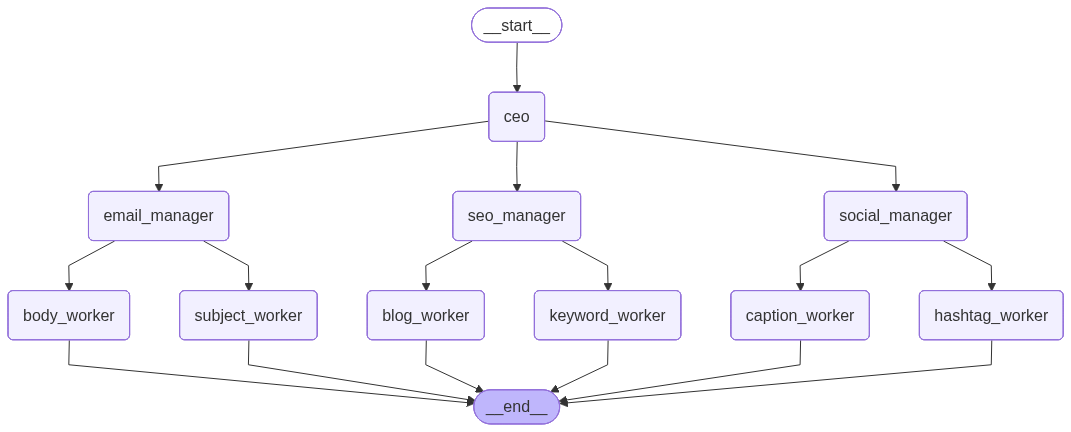

In [44]:
# The graph should look like an org chart:
# CEO at top, 3 managers in middle, 6 workers at bottom.
# Unlike all previous projects, this graph is a TREE not a chain or loop.
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Mermaid diagram (paste at https://mermaid.live):")
    print(app.get_graph().draw_mermaid())

## Step 9 — Helper Runner Function

In [45]:
from IPython.display import Markdown, display


def generate_campaign(product_brief: str, show_briefs: bool = False) -> dict:
    """
    Run the full hierarchical marketing campaign generator.

    Args:
        product_brief: Plain-English description of product + campaign goal
        show_briefs  : True = show all 3 tiers of output
                       False = show only the 6 final deliverables (default)

    Returns:
        final_state dict with all 10 output fields populated
    """
    print("\n" + "="*60)
    print("MARKETING CAMPAIGN GENERATOR")
    print(f"Brief: {product_brief[:70]}...")
    print("="*60)
    print("Hierarchy: CEO -> 3 Managers -> 6 Workers")
    print("9 LLM calls | 6 campaign deliverables")

    initial_state = {
        "product_brief":     product_brief,
        "campaign_strategy": None,
        "seo_brief":         None,
        "social_brief":      None,
        "email_brief":       None,
        "seo_keywords":      None,
        "blog_post":         None,
        "social_captions":   None,
        "hashtag_sets":      None,
        "email_subjects":    None,
        "email_body":        None,
        "messages": [
            {"role": "user", "content": f"Generate campaign for: {product_brief}"}
        ]
    }

    final_state = app.invoke(initial_state)

    # Optionally show intermediate Tier 1 + Tier 2 outputs
    if show_briefs:
        print("\n" + "="*60)
        print("TIER 1 — CEO Campaign Strategy")
        print("="*60)
        display(Markdown(final_state.get("campaign_strategy", "")))

        for label, field in [
            ("TIER 2 — SEO Manager Brief",    "seo_brief"),
            ("TIER 2 — Social Manager Brief", "social_brief"),
            ("TIER 2 — Email Manager Brief",  "email_brief"),
        ]:
            print(f"\n{'─'*60}\n{label}\n{'─'*60}")
            display(Markdown(final_state.get(field, "")))

    # Always show the 6 final content deliverables
    deliverables = [
        ("SEO KEYWORDS",          "seo_keywords"),
        ("BLOG ARTICLE",          "blog_post"),
        ("SOCIAL CAPTIONS",       "social_captions"),
        ("HASHTAG STRATEGY",      "hashtag_sets"),
        ("EMAIL SUBJECT LINES",   "email_subjects"),
        ("EMAIL BODY COPY",       "email_body"),
    ]

    print("\n" + "="*60)
    print("CAMPAIGN DELIVERABLES — 6 CONTENT ASSETS")
    print("="*60)

    for title, field in deliverables:
        print(f"\n{'─'*60}\n{title}\n{'─'*60}")
        display(Markdown(final_state.get(field, "Not available")))

    return final_state


print("generate_campaign() defined!")
print("   result = generate_campaign('Your brief here')")
print("   result = generate_campaign('...', show_briefs=True)")

generate_campaign() defined!
   result = generate_campaign('Your brief here')
   result = generate_campaign('...', show_briefs=True)


## Step 10 — Run the Hierarchy!

Change PRODUCT_BRIEF to generate a campaign for any product.

Good test briefs:
- A fitness app for busy professionals
- An eco-friendly water bottle brand targeting Gen Z
- A B2B project management SaaS for remote teams
- A premium coffee subscription service

In [46]:
# ============================================================
# Change this to generate a campaign for any product!
# ============================================================
PRODUCT_BRIEF = """
Product: FlowFit — AI-powered fitness app for busy professionals.
Features: 10-15 min adaptive workouts, no equipment needed,
learns from your schedule, integrates with Apple Watch.
Price: $14.99/month or $99/year.
Audience: 28-45 year old professionals who struggle to find time for fitness.
Goal: Drive app downloads and 30-day free trial sign-ups.
Tone: Empowering, no-nonsense, premium but approachable.
"""
# ============================================================

result = generate_campaign(PRODUCT_BRIEF.strip(), show_briefs=False)


MARKETING CAMPAIGN GENERATOR
Brief: Product: FlowFit — AI-powered fitness app for busy professionals.
Feat...
Hierarchy: CEO -> 3 Managers -> 6 Workers
9 LLM calls | 6 campaign deliverables

CEO AGENT [Tier 1] — Setting master campaign strategy...
   Brief : Product: FlowFit — AI-powered fitness app for busy professionals.
Features: 10-1...
   Output: campaign_strategy -> read by ALL 3 managers
   Strategy written: 3327 chars
   -> Delegating to SEO Manager, Social Manager, Email Manager

------------------------------------------------------------
EMAIL MANAGER [Tier 2] — Creating email execution plan...
------------------------------------------------------------
   Runs IN PARALLEL with SEO Manager + Social Manager

------------------------------------------------------------
SEO MANAGER [Tier 2] — Creating SEO execution plan...
------------------------------------------------------------
   Runs IN PARALLEL with Social Manager + Email Manager

-------------------------------------

SEO KEYWORD RESEARCH REPORT
===========================

## Primary Keywords (High Priority)
| Keyword | Est. Volume | Difficulty | Intent | Priority |
|---------|-------------|------------|--------|----------|
| quick workouts for busy professionals | 2,900 | 0.65 | Informational/Commercial | High |
| fitness for busy professionals | 1,300 | 0.70 | Informational/Commercial | High |
| home workouts for office workers | 1,000 | 0.60 | Informational/Commercial | Medium |
| AI-powered fitness apps | 820 | 0.75 | Commercial | High |
| workout routines for busy schedules | 500 | 0.55 | Informational | Medium |
| 10-minute workouts | 400 | 0.50 | Informational | Medium |
| busy professional fitness | 320 | 0.65 | Informational/Commercial | Medium |

## Long-Tail Keywords (Quick Wins)
* "quick workout routines for office workers" -> Informational -> Targets busy professionals looking for efficient workout solutions
* "10-minute home workouts for busy professionals" -> Informational -> Provides a specific solution for those with limited time
* "AI-powered fitness for busy professionals" -> Commercial -> Highlights the unique selling point of FlowFit
* "fitness apps for busy professionals" -> Commercial -> Targets those looking for convenient fitness solutions
* "workout routines for busy women" -> Informational -> Targets a specific demographic within the busy professional audience
* "quick workouts for stress relief" -> Informational -> Targets those looking for workouts to reduce stress
* "10-minute workouts for energy boost" -> Informational -> Targets those looking for workouts to increase energy levels
* "busy professional workout plans" -> Informational/Commercial -> Provides a comprehensive solution for busy professionals

## LSI / Semantic Keywords
* fitness motivation
* workout routine
* home exercise
* AI-powered fitness
* busy professional lifestyle
* self-care for professionals
* stress reduction techniques
* energy-boosting workouts
* time management for fitness
* healthy habits for professionals
* wellness for busy professionals
* productivity tips for fitness

## Keyword Clusters
Cluster 1: Quick and Efficient Workouts -> 
  * quick workouts for busy professionals
  * 10-minute workouts
  * home workouts for office workers
  * workout routines for busy schedules
Cluster 2: AI-Powered Fitness and Wellness -> 
  * AI-powered fitness apps
  * AI-powered fitness for busy professionals
  * fitness apps for busy professionals
Cluster 3: Time Management and Productivity for Fitness -> 
  * time management for fitness
  * productivity tips for fitness
  * busy professional workout plans

## Quick Wins (Rank within 30 days)
* "10-minute workouts" ( Difficulty: 0.50, Est. Volume: 400)
* "quick workout routines for office workers" (Difficulty: 0.55, Est. Volume: 210)
* "busy professional fitness" (Difficulty: 0.60, Est. Volume: 140)
* "workout routines for busy women" (Difficulty: 0.55, Est. Volume: 110)
* "quick workouts for stress relief" (Difficulty: 0.50, Est. Volume: 90)

## Notes for Blog Writer
* Primary keyword: "quick workouts for busy professionals" (use 2-3 times in the article, with a density of 1-2%)
* Secondary keywords: "10-minute workouts", "home workouts for office workers", "AI-powered fitness apps" (use 1-2 times each, with a density of 0.5-1%)
* Suggested H1: "10-Minute Workouts for Busy Professionals: How to Fit Fitness into Your Schedule"
* Use a how-to guide format with a listicle structure to provide valuable and actionable tips for the target audience
* Include a clear call-to-action at the end of the article, such as "Sign up for a 30-day free trial of FlowFit and start achieving your fitness goals with adaptive, AI-powered workouts"


────────────────────────────────────────────────────────────
BLOG ARTICLE
────────────────────────────────────────────────────────────


## 10-Minute Workouts for Busy Professionals: How to Fit Fitness into Your Schedule
As a busy professional, finding time for **fitness** can be a daunting task. With long hours at the office, meetings, and deadlines to meet, it's easy to let **exercise** fall by the wayside. However, neglecting your **physical health** can have serious consequences on your **mental well-being**, productivity, and overall **quality of life**. In this article, we'll explore the benefits of **quick and efficient workouts** and provide you with **tips and examples** on how to fit **fitness** into your busy schedule.

### The Challenges of Fitness for Busy Professionals
Let's face it, as a busy professional, you're likely no stranger to **stress**, **lack of energy**, and **guilt** over neglecting your **health**. With so many demands on your time, it can be hard to prioritize **self-care** and **fitness**. But the truth is, **regular exercise** is essential for maintaining your **physical and mental health**, boosting your **productivity**, and improving your overall **work-life balance**.

### Benefits of Quick and Efficient Workouts
So, what are the benefits of **quick and efficient workouts**? Here are just a few:
* **Time-saving**: With **10-minute workouts**, you can fit **exercise** into even the busiest of schedules.
* **Convenience**: Many **quick workouts** can be done **anywhere**, without the need for **special equipment** or a **gym membership**.
* **Increased energy**: Regular **exercise** can help boost your **energy levels** and reduce **fatigue**.
* **Improved mental health**: **Physical activity** can help reduce **stress** and **anxiety**, while also improving your **mood** and **overall sense of well-being**.

### Tips for Incorporating Fitness into a Busy Schedule
So, how can you incorporate **fitness** into your busy schedule? Here are some **tips** to get you started:
* **Schedule it in**: Treat **exercise** as a non-negotiable part of your daily routine, just like **brushing your teeth** or **taking a shower**.
* **Find an exercise you enjoy**: Whether it's **running**, **swimming**, or **yoga**, find an **activity** that you enjoy and that fits your **lifestyle**.
* **Use technology to your advantage**: Utilize **fitness apps** and **wearable devices** to track your **progress**, set **reminders**, and stay **motivated**.
* **Make it a habit**: Consistency is key when it comes to **exercise**. Aim to do some form of **physical activity** every day, even if it's just a **10-minute workout**.

### Examples of 10-Minute Workouts that Can Be Done Anywhere
Here are some **examples** of **10-minute workouts** that can be done **anywhere**:
* **Bodyweight exercises**: **push-ups**, **squats**, **lunges**, and **planks** are all great **exercises** that can be done without any **equipment**.
* **High-intensity interval training (HIIT)**: Alternate between **burpees**, **jumping jacks**, and **mountain climbers** for a **quick and intense workout**.
* **Yoga**: Follow along with a **yoga video** or **app** for a **quick and relaxing workout**.
* **Dance workouts**: Put on your **favorite music** and **dance** like no one's watching for a **fun and energetic workout**.

Some specific **10-minute workout routines** include:
* **Monday (Upper Body)**:
	+ **Push-ups**: 3 sets of 10 reps
	+ **Tricep dips**: 3 sets of 10 reps
	+ **Bicep curls**: 3 sets of 10 reps
* **Tuesday (Lower Body)**:
	+ **Squats**: 3 sets of 10 reps
	+ **Lunges**: 3 sets of 10 reps (per leg)
	+ **Calf raises**: 3 sets of 15 reps
* **Wednesday (Rest Day)**
* **Thursday (Core)**:
	+ **Plank**: 3 sets of 30-second hold
	+ **Russian twists**: 3 sets of 10 reps
	+ **Leg raises**: 3 sets of 10 reps
* **Friday (Total Body)**:
	+ **Burpees**: 3 sets of 10 reps
	+ **Jumping jacks**: 3 sets of 30 seconds
	+ **Mountain climbers**: 3 sets of 30 seconds

### Conclusion and Call-to-Action
Incorporating **fitness** into your busy schedule doesn't have to be difficult. With **quick and efficient workouts**, you can improve your **physical and mental health**, boost your **productivity**, and enhance your overall **quality of life**. At **FlowFit**, we understand the demands of a busy professional's life, which is why we've created an **adaptive, AI-powered fitness app** that provides you with **personalized workouts** and **real-time feedback**. 

Sign up for a **30-day free trial** of **FlowFit** today and start achieving your **fitness goals** with our **expert guidance** and **support**. With **FlowFit**, you'll have access to a **library of workouts**, **nutrition advice**, and **motivational tools** to help you stay on track. Don't let your busy schedule hold you back from achieving your **health and wellness goals**. Try **FlowFit** today and start feeling the benefits of **regular exercise** for yourself! [Sign up now](https://www.flowfit.com/signup)


────────────────────────────────────────────────────────────
SOCIAL CAPTIONS
────────────────────────────────────────────────────────────


...

HASHTAG STRATEGY
================

## Branded Campaign Hashtag
#FitInFlow — This campaign hashtag works because it's unique, memorable, and aligns with the brand name and message. It will help track user-generated content and create a branded community around the campaign.

## Instagram Hashtag Sets
Set A (Reach) : 
- #fitness (430M+)
- #workout (340M+)
- #healthyliving (240M+)
- #wellness (200M+)
- #selfcare (180M+)
- #fitnessmotivation (140M+)
- #gym (120M+)
- #exercise (100M+)
- #weightloss (90M+)
- #nutrition (80M+)
- #fitnessjourney (60M+)
- #health (50M+)
- #lifestyle (40M+)
- #motivation (30M+)
- #inspiration (20M+)

Set B (Niche) : 
- #fitnessforbusyprofessionals (10K+)
- #ai-poweredfitness (5K+)
- #quickworkouts (5K+)
- #wellnessatwork (3K+)
- #corporatewellness (2K+)
- #busylifehacks (2K+)
- #productivityhacks (1K+)
- #fitnessforbeginners (1K+)
- #home workouts (1K+)
- #bodyweightexercises (1K+)
- #mindfulmovement (500+)
- #selflove (500+)
- #mentalhealthmatters (500+)
- #stressmanagement (200+)
- #energyboost (200+)

Set C (Community): 
- #fitnesscommunity (50K+)
- #healthylivingcommunity (20K+)
- #wellnesscommunity (10K+)
- #selfcarecommunity (5K+)
- #fitnessmotivationcommunity (2K+)
- #gymcommunity (1K+)
- #exercise community (1K+)
- #weightlosssupport (500+)
- #nutritionadvice (500+)
- #fitnessjourneycommunity (200+)
- #healthylifestylecommunity (200+)
- #lifestylecommunity (100+)
- #motivationmonday (100+)
- #wellnesswednesday (50+)
- #fitnessfriday (20+)

Strategy: Rotate sets A/B/C across posts to maintain a balance between reach and niche relevance.

## TikTok Hashtags
- #FitInFlow
- #fitnessmotivation (30M+)
- #workoutinspiration (10M+)
- #gym routine (5M+)
- #quickworkouts (2M+)
- #wellnessatwork (1M+)
- #fitnessforbusy (500K+)
- #ai-poweredfitness (200K+)
- #home workouts (100K+)
- #bodyweightexercises (50K+)

## LinkedIn Hashtags
- #FitInFlow
- #healthyliving (1M+)
- #wellnessatwork (500K+)
- #corporatewellness (200K+)
- #productivityhacks (100K+)
- #fitnessforprofessionals (20K+)
- #ai-poweredfitness (10K+)
- #nutritionadvice (5K+)

## Twitter/X Hashtags
- #FitInFlow
- #fitnessmotivation (10M+)
- #workoutinspiration (2M+)
- #wellnesswednesday (1M+)
- #fitnessjourney (500K+)

## Size Mix Guide
| Size | % Use | Purpose |
|------|-------|---------|
| Mega (1M+) | 20% | Broad reach and awareness |
| Macro (100K-1M) | 30% | Niche relevance and community engagement |
| Micro (10K-100K) | 30% | Specific targeting and conversation starters |
| Niche (<10K) | 20% | Hyper-targeting and brand loyalty |

## Hashtags to AVOID
- #getfit (overused and generic)
- #fitnessmodel (not aligned with the brand's tone and audience)
- #gymrat (negative connotations and not inclusive)
- #diet (too restrictive and not aligned with the brand's message)
- #supplements (not relevant to the brand's product and services)


────────────────────────────────────────────────────────────
EMAIL SUBJECT LINES
────────────────────────────────────────────────────────────


## Curiosity-Based (must-open)
A: 🔓 Unlock Your Fitness Potential 🏋️‍♀️
B: 🤔 Can You Get Fit in Just 10 Minutes a Day? 🕒
C: 🚀 Discover the Secret to Fitting Fitness into Your Busy Schedule 📅

## Urgency/Scarcity
A: ⏰ Limited Time: Get Fit in 30 Days with Our Free Trial 📆
B: 🚨 Don't Miss Out: Start Your Fitness Journey Today with FlowFit 🏋️‍♂️
C: 📣 Exclusive Offer: 30-Day Free Trial for Busy Professionals 🎁

## Benefit-Led (what they gain)
A: 💪 Get Fit, Feel Energized, and Boost Your Productivity with FlowFit 📈
B: 🌟 Transform Your Body and Mind with Our Adaptive Workouts 🌱
C: 🕒 Reclaim Your Time: Fitness for Busy Professionals, Made Easy 📅

## Question-Based (personalized)
A: 🤔 Are You Tired of Feeling Guilty About Neglecting Your Health? 🤕
B: 📊 Are You Ready to Upgrade Your Lifestyle and Achieve Your Fitness Goals? 📈

## Casual/Conversational (feels like a friend)
A: 🙋‍♀️ Hey, Let's Get Fit and Feel Amazing Together with FlowFit 🤩
B: 📱 Got 10 Minutes a Day? That's All You Need to Get Started with FlowFit 📅

## TOP 3 RECOMMENDED
1. 🔓 Unlock Your Fitness Potential 🏋️‍♀️ -> Curiosity trigger, expected response: Open to learn more about unlocking fitness potential.
2. 🤔 Can You Get Fit in Just 10 Minutes a Day? 🕒 -> Curiosity trigger, reasoning: Piques the interest of busy professionals by questioning the feasibility of getting fit in a short time frame.
3. ⏰ Limited Time: Get Fit in 30 Days with Our Free Trial 📆 -> Urgency trigger, reasoning: Creates a sense of scarcity and encourages the recipient to take action within a limited time frame.

## A/B Test Recommendation
Test: "🔓 Unlock Your Fitness Potential 🏋️‍♀️" vs "⏰ Limited Time: Get Fit in 30 Days with Our Free Trial 📆" | Variable: Curiosity vs Urgency | Metric: Open rate target (20%) and conversion target (5% of email opens).


────────────────────────────────────────────────────────────
EMAIL BODY COPY
────────────────────────────────────────────────────────────


EMAIL BODY COPY
===============

Preheader: 🏋️‍♀️ Get fit in just 10 minutes a day

---

Hi [First Name],

Are you tired of feeling guilty about neglecting your health and fitness due to your busy schedule? You're not alone. As a busy professional, it can be challenging to find time for the gym or lengthy workout routines. But what if you could get a great workout in just 10 minutes a day?

We know that lack of time is a significant obstacle to fitness, which is why we created FlowFit. Our adaptive workouts are designed to be done anywhere, anytime, and are tailored to your schedule and fitness level. Whether you're a beginner or an experienced athlete, our workouts will help you achieve your fitness goals without sacrificing your precious time.

But don't just take our word for it. Thousands of users have already experienced the benefits of FlowFit, with many seeing significant improvements in their energy levels, stress reduction, and overall well-being. Here's what some of our users have to say:

* "I was skeptical at first, but after just one week of using FlowFit, I noticed a significant increase in my energy levels and a decrease in my stress levels." - Rachel, Age 32
* "I've tried many workout apps before, but FlowFit is the only one that has kept me motivated and engaged. The workouts are challenging, but not overwhelming, and the community support is amazing." - David, Age 41

Our workouts are backed by science, with studies showing that short, intense workouts can be just as effective as longer, more traditional workouts. And with over 100,000 downloads and a 4.5-star rating in the app store, you can trust that you're in good hands.

So why not give FlowFit a try? **Start your 30-day free trial** and experience the benefits of our adaptive workouts for yourself. You can access our app on your phone, tablet, or computer, and start working out anywhere, anytime.

**[Start your 30-day free trial →]** 

P.S. Don't let your busy schedule hold you back from achieving your fitness goals. With FlowFit, you can get fit in just 10 minutes a day, and start feeling more energized, confident, and motivated. Limited spots available for our free trial, so sign up now and start your fitness journey today!

---
[FlowFit] Team

DESIGNER NOTES
==============
- Hero image: A high-energy image of a person working out in a modern, sleek environment, with a cityscape or outdoor scenery in the background.
- CTA button color: #FFC107 (a vibrant, energetic orange color that stands out against a neutral background).
- Mobile note: Ensure that the email is optimized for mobile devices, with a clear and easy-to-read layout, and a prominent call-to-action button that is easy to tap.

## Step 11 — View Full Hierarchy (All 3 Tiers)

In [47]:
# Re-run with show_briefs=True to see how strategy was translated
# down through each tier — this is the most instructive view
# for understanding the Hierarchical architecture.
#
# Watch how:
# CEO strategy is abstract and directional
# Manager briefs are specific and task-oriented
# Worker outputs are polished and ready to publish

result_full = generate_campaign(PRODUCT_BRIEF.strip(), show_briefs=True)


MARKETING CAMPAIGN GENERATOR
Brief: Product: FlowFit — AI-powered fitness app for busy professionals.
Feat...
Hierarchy: CEO -> 3 Managers -> 6 Workers
9 LLM calls | 6 campaign deliverables

CEO AGENT [Tier 1] — Setting master campaign strategy...
   Brief : Product: FlowFit — AI-powered fitness app for busy professionals.
Features: 10-1...
   Output: campaign_strategy -> read by ALL 3 managers
   Strategy written: 3288 chars
   -> Delegating to SEO Manager, Social Manager, Email Manager

------------------------------------------------------------
EMAIL MANAGER [Tier 2] — Creating email execution plan...
------------------------------------------------------------
   Runs IN PARALLEL with SEO Manager + Social Manager

------------------------------------------------------------
SEO MANAGER [Tier 2] — Creating SEO execution plan...
------------------------------------------------------------
   Runs IN PARALLEL with Social Manager + Email Manager

-------------------------------------

MASTER CAMPAIGN STRATEGY
========================

## Campaign Name
Fit In Flow

## Brand Voice and Tone
Confident, empowering, sophisticated, and approachable. We sound like a trusted, high-end fitness coach who understands the demands of a busy professional life, but never talks down or uses overly technical jargon.

## Target Audience
- Primary  : Alexandra, a 32-year-old marketing manager who works 50-hour weeks, values efficiency, and wants to prioritize her health but struggles to find time for traditional workouts.
- Secondary: Jamie, a 40-year-old entrepreneur who travels frequently, is interested in the latest tech trends, and seeks a fitness solution that fits his on-the-go lifestyle.
- Values   : Ambitious, health-conscious, tech-savvy, and eager to optimize their daily routines for better work-life balance.

## Core Campaign Message
FlowFit empowers busy professionals to achieve their fitness goals with personalized, time-efficient workouts that adapt to their unique schedules and lifestyles.

## Key Selling Points
1. **Convenience**: 10-15 minute adaptive workouts that fit into any schedule.
2. **Personalization**: AI-powered workouts tailored to individual goals, schedules, and fitness levels.
3. **Accessibility**: No equipment needed, and seamless integration with Apple Watch for effortless tracking.
4. **Efficiency**: Maximizes workout impact in minimal time, perfect for busy professionals.

## Channel Strategy
- SEO Priority   : Drive organic traffic through targeted keywords like "quick workouts for busy professionals," "AI-powered fitness," and "no-equipment exercises."
- Social Priority: Build a community around the #FlowFitChallenge, showcasing transformative user stories, and sharing engaging content (workout tips, behind-the-scenes, and user-generated content) to drive app downloads and free trial sign-ups.
- Email Priority : Nurture leads through a welcome series highlighting the benefits of FlowFit, offering exclusive tips and content, and encouraging subscribers to start their 30-day free trial.

## What to AVOID
- Overly promotional or spammy content that prioritizes sales over user benefits.
- Using overly complex fitness jargon that might alienate non-experts.
- Focusing solely on the technology aspect, neglecting the human benefits and transformative stories.
- Creating content that feels too generic or doesn't resonate with the target audience's specific pain points.

## Manager Instructions
- To SEO Manager   : Focus on creating high-quality, informative content (blog posts, videos, and guides) that addresses the specific pain points of busy professionals, such as "5-minute morning workouts" or "exercises for office workers."
- To Social Manager: Develop a content calendar that showcases user success stories, sneak peeks of new features, and engaging challenges that encourage audience participation and drive app downloads. Utilize Instagram Reels, Facebook Groups, and Twitter Threads to build a community around FlowFit.
- To Email Manager : Design a welcome series that introduces subscribers to the benefits of FlowFit, provides exclusive workout tips, and offers a clear call-to-action to start the 30-day free trial. Segment the email list to tailor content based on user engagement and preferences.


────────────────────────────────────────────────────────────
TIER 2 — SEO Manager Brief
────────────────────────────────────────────────────────────


SEO CHANNEL BRIEF
=================

## SEO Objective
Drive organic traffic to the FlowFit website, increasing app downloads and 30-day free trial sign-ups by targeting busy professionals searching for convenient, personalized, and efficient fitness solutions.

## To: Keyword Research Worker
- Focus clusters   : 
  1. Quick and efficient workouts (e.g., "10-minute workouts," "quick exercises for busy professionals")
  2. AI-powered fitness and personalization (e.g., "AI-powered workouts," "personalized fitness plans")
  3. No-equipment exercises and bodyweight training (e.g., "no-equipment workouts," "bodyweight exercises for beginners")
  4. Fitness for busy professionals and office workers (e.g., "workout routines for office workers," "exercises for busy professionals")
- Search intent    : Informational and commercial (e.g., "how to stay fit with a busy schedule," "best fitness apps for busy professionals")
- Difficulty range : Medium to high competition (targeting specific, high-intent keywords)
- Volume target    : Specific intent, targeting keywords with moderate to high search volume (e.g., 1,000-10,000 searches per month)

## To: Blog Writing Worker
- Target topic  : "10-Minute Morning Workouts for Busy Professionals: Boost Energy and Productivity"
- Primary keyword: "quick morning workouts"
- Word count    : 1,200-1,500 words
- Format        : How-to guide with a listicle format (e.g., "5 Quick Morning Workouts to Try")
- Key sections  : 
  1. Introduction to the importance of morning workouts for busy professionals
  2. Benefits of quick and efficient morning workouts
  3. 5-7 examples of 10-minute morning workouts (with descriptions and images)
  4. Tips for incorporating morning workouts into a busy schedule
  5. Conclusion with a call-to-action to try FlowFit's adaptive workouts
- CTA at end    : "Start your 30-day free trial with FlowFit and discover personalized, time-efficient workouts that fit your unique schedule and lifestyle."

## SEO Success Metrics
1. Organic traffic growth: Increase website traffic from search engines by 20% within the next 6 months.
2. Keyword ranking improvements: Achieve top 3 rankings for target keywords (e.g., "quick workouts for busy professionals," "AI-powered fitness") within the next 9 months.
3. Conversion rate increase: Boost app downloads and 30-day free trial sign-ups from organic traffic by 15% within the next 12 months.


────────────────────────────────────────────────────────────
TIER 2 — Social Manager Brief
────────────────────────────────────────────────────────────


...

HASHTAG STRATEGY
================

## Branded Campaign Hashtag
#FlowFitChallenge — This hashtag works as it creates a unique identifier for the campaign, encourages user-generated content, and allows for easy tracking of engagement and community building.

## Instagram Hashtag Sets
Set A (Reach) : 
1. #fitness (433M)
2. #workout (346M)
3. #gym (245M)
4. #exercise (184M)
5. #healthyliving (144M)
6. #wellness (133M)
7. #fitnessmotivation (123M)
8. #fitnessjourney (114M)
9. #weightloss (104M)
10. #fitnessinspiration (94M)
11. #health (84M)
12. #fitnesslife (74M)
13. #gymrat (64M)
14. #fitlife (59M)
15. #exercise routine (54M)

Set B (Niche) : 
1. #fitnessforbusyprofessionals (22K)
2. #ai-poweredfitness (15K)
3. #quickworkouts (12K)
4. #noequipmentneeded (10K)
5. #homefitness (9K)
6. #bodyweightexercises (8K)
7. #fitnessondemand (7K)
8. #personalizedfitness (6K)
9. #wellnessatwork (5K)
10. #corporatewellness (4K)
11. #fitnessforwomen (3K)
12. #busylifehacks (2K)
13. #fitnessmotivationforwomen (1K)
14. #quickfit (1K)
15. #fitin10 (500)

Set C (Community): 
1. #fitnesscommunity (55M)
2. #wellnesswednesday (14M)
3. #motivationmonday (12M)
4. #fitnessjourney (10M)
5. #fitfam (8M)
6. #gains (6M)
7. #sweat (5M)
8. #workoutmotivation (4M)
9. #fitnessinspiration (3M)
10. #healthyliving (2M)
11. #wellnesscommunity (1M)
12. #fitnesssupport (500K)
13. #fitnesstips (400K)
14. #workoutroutine (300K)
15. #fitnessadvice (200K)

Strategy: Rotate sets A/B/C across posts to maintain a balance between reach and niche relevance.

## TikTok Hashtags
1. #fitness (2.5B views)
2. #workout (1.5B views)
3. #gym (1B views)
4. #quickworkouts (500M views)
5. #homefitness (300M views)
6. #bodyweightexercises (200M views)
7. #fitnessmotivation (150M views)
8. #fitnessjourney (100M views)
9. #wellness (50M views)
10. #FlowFitChallenge (create a branded challenge)

## LinkedIn Hashtags
1. #fitnessforprofessionals (10K uses)
2. #wellnessatwork (5K uses)
3. #corporatewellness (3K uses)
4. #healthyliving (2K uses)
5. #productivityhacks (1K uses)

## Twitter/X Hashtags
1. #fitness (2M uses)
2. #workout (1M uses)
3. #wellness (500K uses)
4. #fitnessmotivation (200K uses)
5. #FlowFitChallenge (create a branded challenge)

## Size Mix Guide
| Size | % Use | Purpose |
|------|-------|---------|
| Mega (1M+) | 20% | Increase reach and visibility |
| Macro (100K-1M) | 30% | Balance reach and relevance |
| Micro (10K-100K) | 30% | Target specific niches and communities |
| Niche (<10K) | 20% | Highly targeted and specific content |

## Hashtags to AVOID
1. #fitnessmodels (overly competitive and not aligned with the brand voice)
2. #gymshark (competitor brand)
3. #fitnessfail (negative connotation)
4. #gymrat (may be perceived as overly intense or aggressive)
5. #fitnessaddict (may be perceived as unhealthy or obsessive)


────────────────────────────────────────────────────────────
EMAIL SUBJECT LINES
────────────────────────────────────────────────────────────


## Curiosity-Based (must-open)
A: 🏋️‍♀️ What If You Could Fit a Great Workout into Your Busy Schedule? 
B: 💪 Unlock Your Hidden Energy: Discover a Fitness Secret for Busy Professionals 
C: 🤔 Can You Really Get Fit in Just 10 Minutes a Day? 

## Urgency/Scarcity
A: ⏰ Don't Let Your Busy Schedule Hold You Back: Start Your Fitness Journey Now 
B: 📅 Your 30-Day Fitness Transformation Starts Today 
C: 🚀 Blast Off into a Healthier You: Limited Spots Available for Our Free Trial 

## Benefit-Led (what they gain)
A: 💼 Get Fit, Feel Empowered: Transform Your Body and Mind with FlowFit 
B: 🕒 Reclaim Your Time: Efficient Workouts for Busy Professionals 
C: 🌟 Unlock a Healthier, Happier You: Join the FlowFit Community 

## Question-Based (personalized)
A: 🤔 Are You Tired of Feeling Guilty About Your Fitness Routine? 
B: 💭 What's Holding You Back from Achieving Your Fitness Goals? 

## Casual/Conversational (feels like a friend)
A: 🙋‍♀️ Hey, Let's Get Fit Together! 
B: 👋 Ready to Sweat? Let's Do This! 

## TOP 3 RECOMMENDED
1. 🏋️‍♀️ What If You Could Fit a Great Workout into Your Busy Schedule? -> Curiosity trigger, expected response: High open rate due to intriguing question.
2. 💼 Get Fit, Feel Empowered: Transform Your Body and Mind with FlowFit -> Benefit-led, reasoning: Directly communicates the benefits of using FlowFit, appealing to the desire for empowerment and transformation.
3. 🤔 Are You Tired of Feeling Guilty About Your Fitness Routine? -> Question-based, reasoning: Personalized approach that resonates with the target audience's potential feelings of guilt about their current fitness routine.

## A/B Test Recommendation
Test: "🏋️‍♀️ What If You Could Fit a Great Workout into Your Busy Schedule?" vs "⏰ Don't Let Your Busy Schedule Hold You Back: Start Your Fitness Journey Now" | Variable: Curiosity vs Urgency | Metric: Open rate target of 25% to determine which approach resonates more with the target audience.


────────────────────────────────────────────────────────────
EMAIL BODY COPY
────────────────────────────────────────────────────────────


EMAIL BODY COPY
===============

Preheader: Get fit on your own terms 🏋️‍♀️

---

Hi Alexandra,

We know you're busy, but what if you could fit a great workout into your schedule? As a marketing manager, you're no stranger to juggling multiple tasks at once. However, prioritizing your health often takes a backseat. You're not alone - many busy professionals struggle to find time for traditional workouts.

That's where FlowFit comes in - a convenient, personalized, and efficient fitness solution designed specifically for busy professionals like you. Our AI-powered workouts are tailored to your lifestyle, goals, and preferences, ensuring you get the most out of your time. With FlowFit, you can say goodbye to tedious gym commutes and hello to effective, 15-minute workouts that fit seamlessly into your daily routine.

But don't just take our word for it! Our community of 10,000+ busy professionals has already started their fitness journey with FlowFit, achieving remarkable results. Here's what some of our satisfied users have to say:

* "FlowFit has been a game-changer for me. I can finally prioritize my health without sacrificing my busy schedule." - Rachel, Marketing Director
* "I was skeptical at first, but the AI-powered workouts are incredibly effective. I've seen noticeable improvements in my overall fitness and energy levels." - David, Entrepreneur

Our data also speaks for itself: FlowFit users have reported a 30% increase in workout consistency and a 25% improvement in overall fitness levels.

You deserve to prioritize your health, and we're here to help you make it happen. **Start Your 30-Day Free Trial ->** and discover a fitness solution that truly fits your lifestyle.

P.S. As a special welcome gift, you'll get access to our exclusive community of like-minded professionals who share your passion for health and wellness. Join us today and start achieving your fitness goals!

---
[FlowFit] Team

DESIGNER NOTES
==============
- Hero image: A high-quality image of a busy professional working out in a non-traditional setting (e.g., at home, in a park, or during a lunch break) to emphasize the convenience of FlowFit.
- CTA button color: #34C759 (a vibrant, energetic green that encourages action and represents growth).
- Mobile note: Ensure the email is optimized for mobile devices, with a clear and concise layout that allows for easy scrolling and tapping on the CTA button.

## Step 12 — Hierarchy Analytics

In [48]:
# Analyze the hierarchy execution — shows how content grew across tiers

print("=" * 60)
print("HIERARCHY EXECUTION ANALYTICS")
print("=" * 60)

tier_data = [
    ("Tier 0 (User Input)",   [("product_brief",     "Product Brief")]),
    ("Tier 1 (CEO)",          [("campaign_strategy", "Campaign Strategy")]),
    ("Tier 2 (Managers)",     [("seo_brief",         "SEO Brief"),
                                ("social_brief",      "Social Brief"),
                                ("email_brief",       "Email Brief")]),
    ("Tier 3 (Workers)",      [("seo_keywords",      "SEO Keywords"),
                                ("blog_post",         "Blog Post"),
                                ("social_captions",   "Social Captions"),
                                ("hashtag_sets",      "Hashtag Sets"),
                                ("email_subjects",    "Email Subjects"),
                                ("email_body",        "Email Body")]),
]

for tier_name, fields in tier_data:
    total = sum(len(result.get(f, '') or '') for f, _ in fields)
    print(f"\n  {tier_name}  [{total} chars total]")
    for field, label in fields:
        size = len(result.get(field, '') or '')
        print(f"    {label:<22}: {size:>6} chars")

all_fields = ["campaign_strategy", "seo_brief", "social_brief", "email_brief",
               "seo_keywords", "blog_post", "social_captions",
               "hashtag_sets", "email_subjects", "email_body"]
total = sum(len(result.get(f, '') or '') for f in all_fields)

print(f"\n  {'─'*50}")
print(f"  Total content generated : {total:,} chars")
print(f"  LLM calls               : 9 (1+3+6)")
print(f"  Final deliverables      : 6 ready-to-use assets")
print(f"  Serial depth            : 3 hops (CEO->Mgr->Worker)")

print("\nEXECUTION EVENT LOG:")
for i, msg in enumerate(result.get("messages", [])):
    print(f"  [{i}] [{msg['role'].upper():<18}] {msg['content']}")

HIERARCHY EXECUTION ANALYTICS

  Tier 0 (User Input)  [407 chars total]
    Product Brief         :    407 chars

  Tier 1 (CEO)  [3327 chars total]
    Campaign Strategy     :   3327 chars

  Tier 2 (Managers)  [5979 chars total]
    SEO Brief             :   2131 chars
    Social Brief          :   2205 chars
    Email Brief           :   1643 chars

  Tier 3 (Workers)  [19032 chars total]
    SEO Keywords          :   3723 chars
    Blog Post             :   4894 chars
    Social Captions       :   3031 chars
    Hashtag Sets          :   2864 chars
    Email Subjects        :   1809 chars
    Email Body            :   2711 chars

  ──────────────────────────────────────────────────
  Total content generated : 28,338 chars
  LLM calls               : 9 (1+3+6)
  Final deliverables      : 6 ready-to-use assets
  Serial depth            : 3 hops (CEO->Mgr->Worker)

EXECUTION EVENT LOG:
  [0] [USER              ] Generate campaign for: Product: FlowFit — AI-powered fitness app for busy

---

## What You Learned

| Concept | Where |
|---------|-------|
| 3-tier delegation state design | Cell 3 — CampaignState with tier comments |
| CEO sets north star for ALL agents | Cell 4 — all managers + workers read campaign_strategy |
| Manager = translation, not creation | Cell 5 — manager briefs are plans, not content |
| Worker = extreme specialization | Cells 6-8 — each worker does exactly one task |
| Temperature ladder CEO->Mgr->Worker | 0.6 -> 0.3-0.5 -> 0.7-0.9 |
| LangGraph parallelism via multi-edges | Cell 9 — multiple edges from same node |
| No conditional edges in hierarchy | Cell 9 — just add_edge, no routing functions |
| Serial depth vs total calls | 9 total calls, only 3 serial hops |

## All 6 Architecture Final Comparison

```
Architecture   Agents Talk?  Loop?  Parallel?  Routing      Best For
─────────────  ────────────  ─────  ─────────  ───────      ────────
Supervisor     Via state     Yes    No         LLM decides  Dynamic multi-step tasks
Router         No            No     No         LLM classif. Intent-based selection
Sequential     No            No     No         None         Fixed linear pipeline
Collaborative  Yes (debate)  Yes    No         Round count  Decision-making
Hierarchical   Via state     No     YES        None needed  Large parallelizable tasks

Hierarchical's unique power:
  -> Parallelism: managers + workers run simultaneously
  -> Specialization: every worker owns one output field
  -> Scalability: add more workers without touching CEO or managers
  -> Alignment: all 8 agents read CEO strategy = always on-brand
```

## Ideas to Extend
- Add Tier 4: A QA Agent reading all 6 deliverables and checking brand consistency
- Add a Paid Ads Manager as a 4th Tier-2 branch (Google Ads + Meta Ads workers)
- Add Tavily to Blog Worker: search real competitor articles before writing
- Add human-in-the-loop: CEO pauses and awaits approval before briefing managers
- Combine architectures: Router first to pick the right campaign type, then Hierarchy